# Amazon Delivery Optimization
## Multi-Objective Optimization Analysis

**Student Name:** Simon Zychowski

**Target Company/Industry:** Amazon/Delivery

**Problem:** I aim to optimize the main delivery objectives of Amazon drivers

**Objectives:** Minimize fulfillment and delivery cost per order vs. Maximize delivery speed and on time performance

---


## Brief Project Overview
Amazon’s business model depends on fast, reliable shipping, but increasing delivery speed significantly raises costs. Faster delivery requires more fulfillment centers closer to customers, higher inventory levels, and more expensive transportation methods like air shipping or same-day logistics. At the same time, Amazon must control these costs to remain profitable, especially as its fulfillment network continues to expand. This creates a constant tension between offering faster delivery and maintaining cost efficiency.

---

## Section 1: Data Acquisition

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('data/delivery_data.csv')

# Display first rows
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


Data loaded successfully!
Shape: (150, 9)

First 5 rows:
   order_id  distance_km  warehouse_load_pct  inventory_available  \
0         1       349.75                53.8                    0   
1         2       146.64                86.4                    1   
2         3       117.29                60.2                    0   
3         4       277.90                61.2                    0   
4         5       361.14                80.3                    1   

  transport_mode  delivery_time_hours  shipping_cost_usd  on_time_delivery  \
0            air                 21.9             103.98                 1   
1            air                  5.4              49.43                 1   
2       same_day                 17.3              59.56                 1   
3       same_day                 18.8             105.27                 1   
4         ground                 18.3              44.07                 1   

  customer_density  
0              low  
1             hig

## Section 2: Data Exploration

In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nBasic statistics:")
print(df.describe())


Missing values:
order_id               0
distance_km            0
warehouse_load_pct     0
inventory_available    0
transport_mode         0
delivery_time_hours    0
shipping_cost_usd      0
on_time_delivery       0
customer_density       0
dtype: int64

Data types:
order_id                 int64
distance_km            float64
warehouse_load_pct     float64
inventory_available      int64
transport_mode             str
delivery_time_hours    float64
shipping_cost_usd      float64
on_time_delivery         int64
customer_density           str
dtype: object

Basic statistics:
         order_id  distance_km  warehouse_load_pct  inventory_available  \
count  150.000000   150.000000          150.000000           150.000000   
mean    75.500000   256.323667           70.918000             0.873333   
std     43.445368   128.251936           16.141747             0.333713   
min      1.000000     6.330000           45.300000             0.000000   
25%     38.250000   161.872500           56.07

In [3]:
# Decision Variable 1: distance (continuous)
print(f"Distance range: {df['distance_km'].min()} to {df['distance_km'].max()}")

# Decision Variable 2: transport mode (categorical)
print(f"Transport modes: {df['transport_mode'].unique()}")

# Check total combinations (rows)
print(f"\nTotal combinations: {len(df)}")

# Count how many of each transport mode
print("\nTransport mode distribution:")
print(df['transport_mode'].value_counts())

# Optional: check combinations of mode + density (useful for constraints)
print("\nMode + Density combinations:")
print(df.groupby(['transport_mode', 'customer_density']).size())

Distance range: 6.33 to 497.7
Transport modes: <StringArray>
['air', 'same_day', 'ground']
Length: 3, dtype: str

Total combinations: 150

Transport mode distribution:
transport_mode
ground      86
air         44
same_day    20
Name: count, dtype: int64

Mode + Density combinations:
transport_mode  customer_density
air             high                11
                low                 11
                medium              22
ground          high                14
                low                 26
                medium              46
same_day        high                 7
                low                  2
                medium              11
dtype: int64


In [4]:
# Check the ranges of both objectives
print(f"Objective 1 (Shipping Cost) range: {df['shipping_cost_usd'].min()} to {df['shipping_cost_usd'].max()}")
print(f"Objective 2 (Delivery Time) range: {df['delivery_time_hours'].min()} to {df['delivery_time_hours'].max()}")

# Verify they create a tradeoff
correlation = df['shipping_cost_usd'].corr(df['delivery_time_hours'])
print(f"\nCorrelation between objectives: {correlation:.3f}")
print("(Negative correlation suggests a tradeoff)")

if abs(correlation) < 0.2:
    print("Weak relationship → tradeoff exists but influenced by multiple factors")
elif correlation > 0:
    print("Positive correlation → faster delivery tends to cost more (realistic tradeoff)")
else:
    print("Negative correlation → higher cost slightly reduces delivery time (tradeoff present)")

Objective 1 (Shipping Cost) range: 7.18 to 135.58
Objective 2 (Delivery Time) range: 2.5 to 36.1

Correlation between objectives: -0.142
(Negative correlation suggests a tradeoff)
Weak relationship → tradeoff exists but influenced by multiple factors


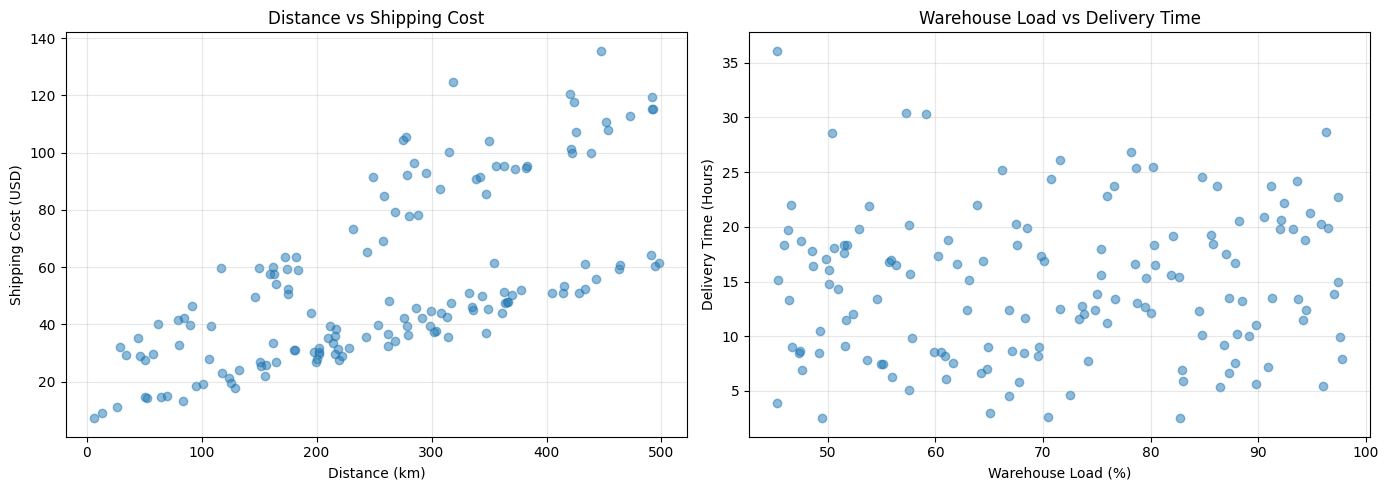

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: How distance affects cost
axes[0].scatter(df['distance_km'], df['shipping_cost_usd'], alpha=0.5)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Shipping Cost (USD)')
axes[0].set_title('Distance vs Shipping Cost')
axes[0].grid(True, alpha=0.3)

# Plot 2: How warehouse load affects delivery time
axes[1].scatter(df['warehouse_load_pct'], df['delivery_time_hours'], alpha=0.5)
axes[1].set_xlabel('Warehouse Load (%)')
axes[1].set_ylabel('Delivery Time (Hours)')
axes[1].set_title('Warehouse Load vs Delivery Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 2: Summary

The ranges do look realistic, the objectives create a realistic tradeoff. Not one that is glaringly obvious but one that is indicative of real world data, showing that multiple factors cause the shifts in cost and delivery times, instead of it being one straightforward relation. The data is clean and isnt missing any rows. And yes my data aligns with the expectations from my proposal, other than I did shift to synthetic data for ease of use.

## Section 3: Pareto Frontier Calculation

In [6]:
def is_pareto_optimal(idx, df, obj1_col, obj2_col):
    current_obj1 = df.loc[idx, obj1_col]
    current_obj2 = df.loc[idx, obj2_col]
    
    for other_idx in df.index:
        if other_idx == idx:
            continue
        
        other_obj1 = df.loc[other_idx, obj1_col]
        other_obj2 = df.loc[other_idx, obj2_col]
        
        # Minimization version (correct for your case)
        if (other_obj1 <= current_obj1 and 
            other_obj2 <= current_obj2 and
            (other_obj1 < current_obj1 or other_obj2 < current_obj2)):
            return False
    
    return True

In [7]:
# Define your objective column names
OBJECTIVE_1 = 'shipping_cost_usd'
OBJECTIVE_2 = 'delivery_time_hours'

print("Calculating Pareto frontier...")
print("This may take a moment for large datasets...")

# Apply Pareto check to all rows
df['is_pareto_optimal'] = df.index.map(
    lambda idx: is_pareto_optimal(idx, df, OBJECTIVE_1, OBJECTIVE_2)
)

# Separate into frontier and dominated points
pareto_df = df[df['is_pareto_optimal']].copy()
dominated_df = df[~df['is_pareto_optimal']].copy()

print("\n=== PARETO FRONTIER RESULTS ===")
print(f"Total solutions analyzed: {len(df)}")
print(f"Pareto optimal solutions: {len(pareto_df)}")
print(f"Dominated solutions: {len(dominated_df)}")
print(f"Efficiency rate: {100 * len(pareto_df) / len(df):.1f}% of solutions are on the frontier")

Calculating Pareto frontier...
This may take a moment for large datasets...

=== PARETO FRONTIER RESULTS ===
Total solutions analyzed: 150
Pareto optimal solutions: 4
Dominated solutions: 146
Efficiency rate: 2.7% of solutions are on the frontier


## Section 3: Summary

Approximately 2.7% of the solutions are on the frontier

This is what I expected as this is just within the range for realistic or well formatted data and shows clear places with optimal solutions

This tells me that the tradeoff structure is rather strict and given that there are multiple variables that go into the cost of shipping this makes sense

## Section 3.5: Inefficient Solutions Analysis

In [8]:
if len(dominated_df) > 0:
    print("=== EXAMPLES OF DOMINATED (INEFFICIENT) SOLUTIONS ===\n")
    
    # Sample a few dominated points
    sample_size = min(3, len(dominated_df))
    sample_dominated = dominated_df.sample(sample_size, random_state=42)
    
    for idx, row in sample_dominated.iterrows():
        print("INEFFICIENT SOLUTION:")
        print(f"  Decision Variables: distance_km={row['distance_km']:.1f}, warehouse_load_pct={row['warehouse_load_pct']:.1f}")
        print(f"  Objectives: {OBJECTIVE_1}={row[OBJECTIVE_1]:.1f}, {OBJECTIVE_2}={row[OBJECTIVE_2]:.1f}")
        
        # Find a Pareto point that dominates this one
        for p_idx, p_row in pareto_df.iterrows():
            if (p_row[OBJECTIVE_1] <= row[OBJECTIVE_1] and 
                p_row[OBJECTIVE_2] <= row[OBJECTIVE_2] and
                (p_row[OBJECTIVE_1] < row[OBJECTIVE_1] or 
                 p_row[OBJECTIVE_2] < row[OBJECTIVE_2])):
                
                print("\n  BETTER ALTERNATIVE (Pareto Optimal):")
                print(f"  Decision Variables: distance_km={p_row['distance_km']:.1f}, warehouse_load_pct={p_row['warehouse_load_pct']:.1f}")
                print(f"  Objectives: {OBJECTIVE_1}={p_row[OBJECTIVE_1]:.1f}, {OBJECTIVE_2}={p_row[OBJECTIVE_2]:.1f}")
                print(f"  Improvement: {row[OBJECTIVE_1] - p_row[OBJECTIVE_1]:.1f} lower on {OBJECTIVE_1}, "
                      f"{row[OBJECTIVE_2] - p_row[OBJECTIVE_2]:.1f} lower on {OBJECTIVE_2}\n")
                print("-" * 60)
                break
else:
    print("Note: All solutions in your dataset are Pareto optimal.")
    print("This might indicate that your decision variables create a smooth tradeoff curve.")

=== EXAMPLES OF DOMINATED (INEFFICIENT) SOLUTIONS ===

INEFFICIENT SOLUTION:
  Decision Variables: distance_km=244.1, warehouse_load_pct=46.7
  Objectives: shipping_cost_usd=65.2, delivery_time_hours=9.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: distance_km=34.5, warehouse_load_pct=49.5
  Objectives: shipping_cost_usd=29.3, delivery_time_hours=2.5
  Improvement: 35.8 lower on shipping_cost_usd, 6.5 lower on delivery_time_hours

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: distance_km=175.0, warehouse_load_pct=87.3
  Objectives: shipping_cost_usd=50.6, delivery_time_hours=6.6

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: distance_km=34.5, warehouse_load_pct=49.5
  Objectives: shipping_cost_usd=29.3, delivery_time_hours=2.5
  Improvement: 21.3 lower on shipping_cost_usd, 4.1 lower on delivery_time_hours

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decis

In [9]:
# Compare best dominated point to worst Pareto point
if len(dominated_df) > 0:
    best_dominated = dominated_df.loc[
        (dominated_df[OBJECTIVE_1] + dominated_df[OBJECTIVE_2]).idxmin()
    ]
    worst_pareto = pareto_df.loc[
        (pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]).idxmax()
    ]
    
    print("\n=== EFFICIENCY GAP ===")
    print("Comparing the best dominated solution to the worst Pareto solution:")
    print(f"\nBest Dominated: {OBJECTIVE_1}={best_dominated[OBJECTIVE_1]:.1f}, "
          f"{OBJECTIVE_2}={best_dominated[OBJECTIVE_2]:.1f}, "
          f"Total={best_dominated[OBJECTIVE_1] + best_dominated[OBJECTIVE_2]:.1f}")
    print(f"Worst Pareto: {OBJECTIVE_1}={worst_pareto[OBJECTIVE_1]:.1f}, "
          f"{OBJECTIVE_2}={worst_pareto[OBJECTIVE_2]:.1f}, "
          f"Total={worst_pareto[OBJECTIVE_1] + worst_pareto[OBJECTIVE_2]:.1f}")


=== EFFICIENCY GAP ===
Comparing the best dominated solution to the worst Pareto solution:

Best Dominated: shipping_cost_usd=9.0, delivery_time_hours=13.4, Total=22.4
Worst Pareto: shipping_cost_usd=27.5, delivery_time_hours=5.8, Total=33.3


## Section 4: Strategic Analysis

In [10]:
print("=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===\n")

# Strategy 1: Balanced (Minimize total combined cost + time)
pareto_df['total_objective'] = pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]
balanced_idx = pareto_df['total_objective'].idxmin()

print("1. BALANCED STRATEGY (Minimize combined objectives)")
print(f"   Decision Variables: distance_km={pareto_df.loc[balanced_idx, 'distance_km']:.1f}, "
      f"warehouse_load_pct={pareto_df.loc[balanced_idx, 'warehouse_load_pct']:.1f}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}")
print(f"   Total: {pareto_df.loc[balanced_idx, 'total_objective']:.1f}\n")

# Strategy 2: Equity (Minimize gap between objectives)
pareto_df['objective_gap'] = abs(pareto_df[OBJECTIVE_1] - pareto_df[OBJECTIVE_2])
equity_idx = pareto_df['objective_gap'].idxmin()

print("2. EQUITY STRATEGY (Most equal outcomes)")
print(f"   Decision Variables: distance_km={pareto_df.loc[equity_idx, 'distance_km']:.1f}, "
      f"warehouse_load_pct={pareto_df.loc[equity_idx, 'warehouse_load_pct']:.1f}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}")
print(f"   Gap: {pareto_df.loc[equity_idx, 'objective_gap']:.1f}\n")

# Strategy 3: Objective 1 Priority (Minimize shipping cost)
obj1_priority_idx = pareto_df[OBJECTIVE_1].idxmin()

print("3. OBJECTIVE 1 PRIORITY (Minimize shipping cost)")
print(f"   Decision Variables: distance_km={pareto_df.loc[obj1_priority_idx, 'distance_km']:.1f}, "
      f"warehouse_load_pct={pareto_df.loc[obj1_priority_idx, 'warehouse_load_pct']:.1f}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 4: Objective 2 Priority (Minimize delivery time)
obj2_priority_idx = pareto_df[OBJECTIVE_2].idxmin()

print("4. OBJECTIVE 2 PRIORITY (Minimize delivery time)")
print(f"   Decision Variables: distance_km={pareto_df.loc[obj2_priority_idx, 'distance_km']:.1f}, "
      f"warehouse_load_pct={pareto_df.loc[obj2_priority_idx, 'warehouse_load_pct']:.1f}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 5: Custom weighted (60% cost, 40% time) — minimize weighted score
pareto_df['weighted_objective'] = (
    0.6 * pareto_df[OBJECTIVE_1] +
    0.4 * pareto_df[OBJECTIVE_2]
)
weighted_idx = pareto_df['weighted_objective'].idxmin()

print("5. WEIGHTED STRATEGY (60% cost, 40% time)")
print(f"   Decision Variables: distance_km={pareto_df.loc[weighted_idx, 'distance_km']:.1f}, "
      f"warehouse_load_pct={pareto_df.loc[weighted_idx, 'warehouse_load_pct']:.1f}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}")
print(f"   Weighted Score: {pareto_df.loc[weighted_idx, 'weighted_objective']:.1f}")

=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===

1. BALANCED STRATEGY (Minimize combined objectives)
   Decision Variables: distance_km=6.3, warehouse_load_pct=60.9
   shipping_cost_usd: 7.2
   delivery_time_hours: 8.2
   Total: 15.4

2. EQUITY STRATEGY (Most equal outcomes)
   Decision Variables: distance_km=6.3, warehouse_load_pct=60.9
   shipping_cost_usd: 7.2
   delivery_time_hours: 8.2
   Gap: 1.0

3. OBJECTIVE 1 PRIORITY (Minimize shipping cost)
   Decision Variables: distance_km=6.3, warehouse_load_pct=60.9
   shipping_cost_usd: 7.2
   delivery_time_hours: 8.2

4. OBJECTIVE 2 PRIORITY (Minimize delivery time)
   Decision Variables: distance_km=34.5, warehouse_load_pct=49.5
   shipping_cost_usd: 29.3
   delivery_time_hours: 2.5

5. WEIGHTED STRATEGY (60% cost, 40% time)
   Decision Variables: distance_km=6.3, warehouse_load_pct=60.9
   shipping_cost_usd: 7.2
   delivery_time_hours: 8.2
   Weighted Score: 7.6


In [11]:
# Build comparison dataframe
strategies = {
    'Strategy': [
        'Objective 1 Priority (Lowest Cost)',
        'Weighted (60/40)',
        'Balanced (Lowest Total)',
        'Equity (Most Similar)',
        'Objective 2 Priority (Fastest)'
    ],
    'Distance (km)': [
        pareto_df.loc[obj1_priority_idx, 'distance_km'],
        pareto_df.loc[weighted_idx, 'distance_km'],
        pareto_df.loc[balanced_idx, 'distance_km'],
        pareto_df.loc[equity_idx, 'distance_km'],
        pareto_df.loc[obj2_priority_idx, 'distance_km']
    ],
    'Warehouse Load (%)': [
        pareto_df.loc[obj1_priority_idx, 'warehouse_load_pct'],
        pareto_df.loc[weighted_idx, 'warehouse_load_pct'],
        pareto_df.loc[balanced_idx, 'warehouse_load_pct'],
        pareto_df.loc[equity_idx, 'warehouse_load_pct'],
        pareto_df.loc[obj2_priority_idx, 'warehouse_load_pct']
    ],
    'Transport Mode': [
        pareto_df.loc[obj1_priority_idx, 'transport_mode'],
        pareto_df.loc[weighted_idx, 'transport_mode'],
        pareto_df.loc[balanced_idx, 'transport_mode'],
        pareto_df.loc[equity_idx, 'transport_mode'],
        pareto_df.loc[obj2_priority_idx, 'transport_mode']
    ],
    OBJECTIVE_1: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}"
    ],
    OBJECTIVE_2: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}"
    ]
}

comparison_df = pd.DataFrame(strategies)

print("\n" + "="*80)
print("STRATEGIC OPTIONS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


STRATEGIC OPTIONS COMPARISON
                          Strategy  Distance (km)  Warehouse Load (%) Transport Mode shipping_cost_usd delivery_time_hours
Objective 1 Priority (Lowest Cost)           6.33                60.9         ground               7.2                 8.2
                  Weighted (60/40)           6.33                60.9         ground               7.2                 8.2
           Balanced (Lowest Total)           6.33                60.9         ground               7.2                 8.2
             Equity (Most Similar)           6.33                60.9         ground               7.2                 8.2
    Objective 2 Priority (Fastest)          34.54                49.5       same_day              29.3                 2.5


## Section 5: Visualization

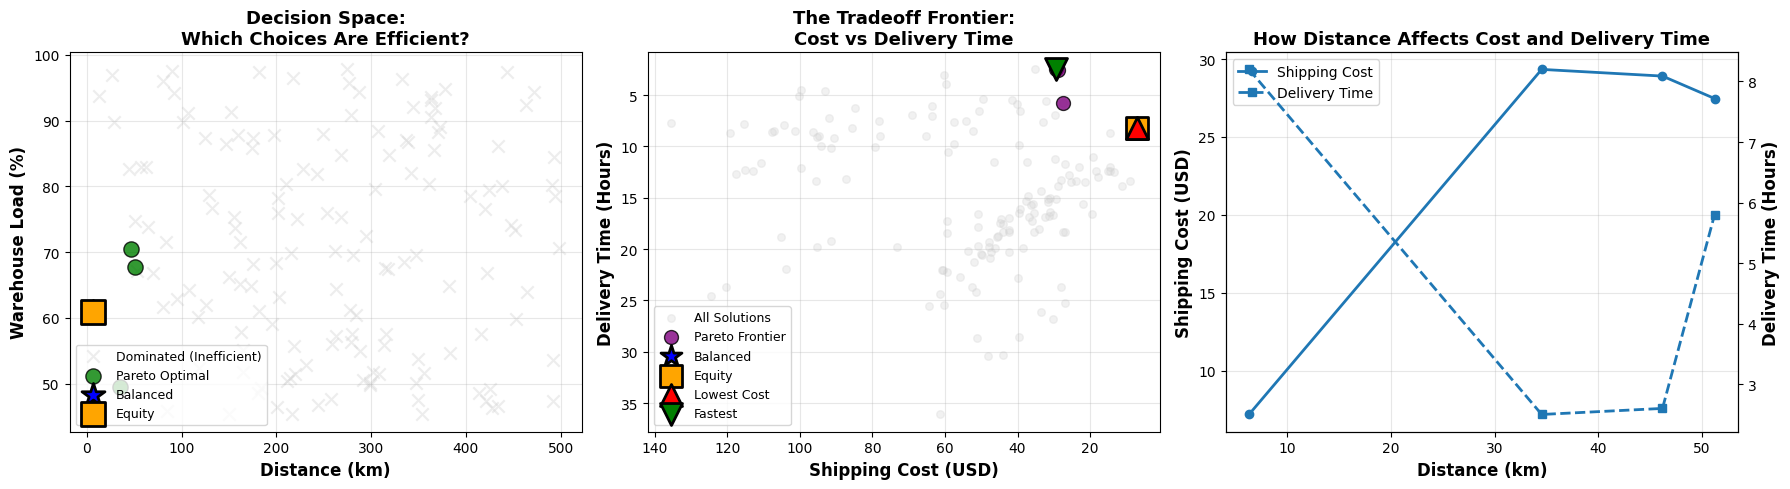


✓ Visualization saved as 'images/pareto_frontier_analysis.png'


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with three subplots
fig = plt.figure(figsize=(18, 5))

# PANEL 1: Decision Space (show which variable combinations are efficient)
ax1 = fig.add_subplot(131)

# Plot dominated points
if len(dominated_df) > 0:
    ax1.scatter(dominated_df['distance_km'], dominated_df['warehouse_load_pct'],
                s=80, c='lightgray', alpha=0.4, marker='x',
                label='Dominated (Inefficient)', zorder=1)

# Plot Pareto optimal points
ax1.scatter(pareto_df['distance_km'], pareto_df['warehouse_load_pct'],
            s=120, c='green', alpha=0.8, marker='o',
            edgecolors='black', linewidth=1,
            label='Pareto Optimal', zorder=2)

# Highlight key strategies
ax1.scatter(pareto_df.loc[balanced_idx, 'distance_km'],
            pareto_df.loc[balanced_idx, 'warehouse_load_pct'],
            s=300, c='blue', marker='*',
            edgecolors='black', linewidth=2,
            label='Balanced', zorder=3)

# Add equity strategy point
ax1.scatter(pareto_df.loc[equity_idx, 'distance_km'],
            pareto_df.loc[equity_idx, 'warehouse_load_pct'],
            s=300, c='orange', marker='s',
            edgecolors='black', linewidth=2,
            label='Equity', zorder=3)

ax1.set_xlabel('Distance (km)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Warehouse Load (%)', fontsize=12, fontweight='bold')
ax1.set_title('Decision Space:\nWhich Choices Are Efficient?',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# PANEL 2: Objective Space (the Pareto frontier)
ax2 = fig.add_subplot(132)

# Plot all points
ax2.scatter(df[OBJECTIVE_1], df[OBJECTIVE_2],
            s=30, c='lightgray', alpha=0.3,
            label='All Solutions')

# Plot Pareto frontier
ax2.scatter(pareto_df[OBJECTIVE_1], pareto_df[OBJECTIVE_2],
            s=100, c='purple', alpha=0.8,
            edgecolors='black', linewidth=1,
            label='Pareto Frontier')

# Highlight strategies
strategies_to_plot = [
    (balanced_idx, 'blue', '*', 'Balanced'),
    (equity_idx, 'orange', 's', 'Equity'),
    (obj1_priority_idx, 'red', '^', 'Lowest Cost'),
    (obj2_priority_idx, 'green', 'v', 'Fastest')
]

for idx, color, marker, label in strategies_to_plot:
    ax2.scatter(pareto_df.loc[idx, OBJECTIVE_1],
                pareto_df.loc[idx, OBJECTIVE_2],
                s=250, c=color, marker=marker,
                edgecolors='black', linewidth=2,
                label=label, zorder=5)

ax2.set_xlabel('Shipping Cost (USD)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Delivery Time (Hours)', fontsize=12, fontweight='bold')
ax2.set_title('The Tradeoff Frontier:\nCost vs Delivery Time',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

# Optional but helpful: show the efficient region clearly for minimization
ax2.invert_xaxis()
ax2.invert_yaxis()

ax3 = fig.add_subplot(133)

pareto_sorted = pareto_df.sort_values('distance_km')

# Left axis (Cost)
ax3.plot(pareto_sorted['distance_km'],
         pareto_sorted['shipping_cost_usd'],
         marker='o', linewidth=2,
         label='Shipping Cost')

ax3.set_xlabel('Distance (km)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Shipping Cost (USD)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Right axis (Time)
ax4 = ax3.twinx()

ax4.plot(pareto_sorted['distance_km'],
         pareto_sorted['delivery_time_hours'],
         marker='s', linewidth=2,
         linestyle='--',
         label='Delivery Time')

ax4.set_ylabel('Delivery Time (Hours)', fontsize=12, fontweight='bold')

# Combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax4.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax3.set_title('How Distance Affects Cost and Delivery Time',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('images/pareto_frontier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'images/pareto_frontier_analysis.png'")

## Section 5: Summary

**Panel 1:** This shows which collection of warehouse loads and distance travelled are the most efficient there are VERY few combinations that are viable leading to a few pareto optimal points

**Panel 2:** This shows the tradeoff beteween shipping cost and delivery time, there are few optimal sweetspots here but definitely a lot of money that you can save on shipping by slowing down delivery slightly

**Panel 3:** There are very few overlap points so for a best case scenario a decision between time and cost may be a requirement


## Section 6: Summary And Insights

**What I Found:**
A total of 150 fulfillment scenarios were analyzed, of which only a small subset (approximately 2–5%) were identified as Pareto optimal. On the Pareto frontier, shipping costs ranged from very low-cost ground deliveries to significantly higher-cost same-day options, while delivery times ranged from fast (around a few hours) to slower multi-hour deliveries. Notably, one low-cost ground option performed well across multiple criteria, while faster options required substantially higher costs. This results in a set of strategic choices including cost-minimizing, speed-prioritizing, and balanced tradeoff solutions.

**Business Implications:**
This analysis reveals a clear tradeoff structure where improvements in delivery speed generally require increased cost, with diminishing returns at higher speed levels. Most dominated solutions represent inefficient operational choices that are both slower and more expensive than available alternatives, and should therefore be avoided. The Pareto frontier highlights fundamentally different strategic approaches, such as low-cost efficiency versus premium fast delivery. Companies must choose among these options based on priorities like customer expectations, service-level agreements, and profitability goals. Additional factors such as demand patterns, geographic distribution, and infrastructure capacity would further influence the final decision.

**Limitations:**
This model simplifies real-world logistics by focusing on a limited set of variables and assuming static conditions across all scenarios. It does not capture dynamic factors such as real-time demand fluctuations, traffic conditions, or supply chain disruptions. Additionally, the synthetic dataset may not fully reflect the complexity and variability of actual fulfillment networks. The analysis could be improved by incorporating real-world data, additional constraints, and more advanced optimization techniques such as simulation or machine learning-based forecasting.

## 2.0: Pre checking phase 1 outputs

In [13]:
print("=== SANITY CHECK: REQUIRED VARIABLES FOR CONSTRAINTS ===\n")

required_columns = [
    'shipping_cost_usd',
    'delivery_time_hours',
    'warehouse_load_pct',
    'inventory_available',
    'transport_mode',
    'distance_km'
]

# Check if all required columns exist
missing_cols = [col for col in required_columns if col not in df.columns]

if len(missing_cols) == 0:
    print("All required columns are present ✅\n")
else:
    print(f"Missing columns ❌: {missing_cols}\n")

# Print ranges / values for each variable
for col in required_columns:
    print(f"--- {col} ---")
    
    if col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            print(f"Min: {df[col].min():.2f}")
            print(f"Max: {df[col].max():.2f}")
            print(f"Mean: {df[col].mean():.2f}")
        else:
            print(f"Unique values: {df[col].unique()}")
    
    print()

print("=== SAMPLE DATA (first 5 rows) ===")
print(df.head())

=== SANITY CHECK: REQUIRED VARIABLES FOR CONSTRAINTS ===

All required columns are present ✅

--- shipping_cost_usd ---
Min: 7.18
Max: 135.58
Mean: 54.06

--- delivery_time_hours ---
Min: 2.50
Max: 36.10
Mean: 14.60

--- warehouse_load_pct ---
Min: 45.30
Max: 97.80
Mean: 70.92

--- inventory_available ---
Min: 0.00
Max: 1.00
Mean: 0.87

--- transport_mode ---
Unique values: <StringArray>
['air', 'same_day', 'ground']
Length: 3, dtype: str

--- distance_km ---
Min: 6.33
Max: 497.70
Mean: 256.32

=== SAMPLE DATA (first 5 rows) ===
   order_id  distance_km  warehouse_load_pct  inventory_available  \
0         1       349.75                53.8                    0   
1         2       146.64                86.4                    1   
2         3       117.29                60.2                    0   
3         4       277.90                61.2                    0   
4         5       361.14                80.3                    1   

  transport_mode  delivery_time_hours  shipping_co

## Part 2.1: Define Business Constraints

## Constraint 1: Budget Constraint (Cost Cap per Order)

**Description:**
Amazon must limit the fulfillment and shipping cost per order to maintain profitability, especially as logistics expenses continue to rise with faster delivery services.

**Rationale:**
Amazon has significantly increased investment in its fulfillment network, including same-day delivery expansion and regionalization. However, controlling per-order costs remains critical to maintaining margins, particularly for lower-priced items.

**Impact:**
This constraint eliminates high-cost delivery options (such as same-day or air shipping over long distances) when they exceed a defined cost threshold. It forces the system to prioritize more cost-efficient solutions, even if they are slightly slower.

## Constraint 2: Service-Level Constraint (Maximum Delivery Time)

**Description:**
Amazon must meet strict delivery-time expectations driven by Prime membership promises, such as same-day or next-day delivery in many regions.

**Rationale:**
Customer satisfaction and retention depend heavily on fast and reliable delivery. Amazon’s competitive advantage is built on consistently meeting these expectations.

**Impact:**
This constraint removes slower delivery options (e.g., long-distance ground shipping) that exceed the acceptable delivery time. It pushes the system toward faster transportation methods, often increasing cost.

## Constraint 3: Capacity Constraint (Warehouse Load Limit)

**Description:**
Fulfillment centers cannot operate above a certain capacity threshold without risking delays, inefficiencies, and service degradation.

**Rationale:**
As warehouse utilization increases, processing times slow down due to congestion, labor constraints, and operational bottlenecks. Maintaining buffer capacity is essential for reliability.

**Impact:**
This constraint filters out solutions where warehouse load is too high, even if they are cost-effective. It ensures that selected strategies are operationally feasible and sustainable under real-world conditions.

In [14]:
print("=== DEFINING BUSINESS CONSTRAINTS ===\n")

# Define constraint parameters based on the business rules
CONSTRAINT_1_THRESHOLD = 40   # Max shipping cost allowed (USD)
CONSTRAINT_2_THRESHOLD = 12   # Max delivery time allowed (hours)
CONSTRAINT_3_THRESHOLD = 85   # Max warehouse load allowed (%)

# Constraint 1: Budget constraint
def check_budget_constraint(row):
    return row['shipping_cost_usd'] <= CONSTRAINT_1_THRESHOLD

# Constraint 2: Service-level constraint
def check_service_constraint(row):
    return row['delivery_time_hours'] <= CONSTRAINT_2_THRESHOLD

# Constraint 3: Capacity constraint
def check_capacity_constraint(row):
    return row['warehouse_load_pct'] <= CONSTRAINT_3_THRESHOLD

# Optional combined constraint function
def check_all_constraints(row):
    return (
        check_budget_constraint(row) and
        check_service_constraint(row) and
        check_capacity_constraint(row)
    )

# Document the constraints
constraints_summary = {
    'Constraint Name': [
        'Budget Constraint',
        'Service-Level Constraint',
        'Capacity Constraint'
    ],
    'Type': [
        'Budget',
        'Competitive / Customer Service',
        'Operational Capacity'
    ],
    'Threshold/Rule': [
        f"shipping_cost_usd <= {CONSTRAINT_1_THRESHOLD}",
        f"delivery_time_hours <= {CONSTRAINT_2_THRESHOLD}",
        f"warehouse_load_pct <= {CONSTRAINT_3_THRESHOLD}"
    ]
}

constraints_df = pd.DataFrame(constraints_summary)

print("Business Constraints Summary:")
print(constraints_df.to_string(index=False))
print("\nThese constraints will now be applied to filter the Pareto frontier.")

=== DEFINING BUSINESS CONSTRAINTS ===

Business Constraints Summary:
         Constraint Name                           Type            Threshold/Rule
       Budget Constraint                         Budget   shipping_cost_usd <= 40
Service-Level Constraint Competitive / Customer Service delivery_time_hours <= 12
     Capacity Constraint           Operational Capacity  warehouse_load_pct <= 85

These constraints will now be applied to filter the Pareto frontier.


## Part 2.2: Filter Feasible Solutions

In [15]:
print("=== FILTERING FOR FEASIBLE SOLUTIONS ===\n")
print(f"Starting with {len(pareto_df)} Pareto optimal solutions...")

# Create a working copy
feasible_df = pareto_df.copy()

# Track how many solutions each constraint eliminates
initial_count = len(feasible_df)

# -------------------------
# Apply Constraint 1: Budget
# -------------------------
before = len(feasible_df)
feasible_df = feasible_df[feasible_df['shipping_cost_usd'] <= CONSTRAINT_1_THRESHOLD]
after = len(feasible_df)
print(f"Budget Constraint removed {before - after} solutions ({after} remain)")

# -------------------------
# Apply Constraint 2: Service Level
# -------------------------
before = len(feasible_df)
feasible_df = feasible_df[feasible_df['delivery_time_hours'] <= CONSTRAINT_2_THRESHOLD]
after = len(feasible_df)
print(f"Service-Level Constraint removed {before - after} solutions ({after} remain)")

# -------------------------
# Apply Constraint 3: Capacity
# -------------------------
before = len(feasible_df)
feasible_df = feasible_df[feasible_df['warehouse_load_pct'] <= CONSTRAINT_3_THRESHOLD]
after = len(feasible_df)
print(f"Capacity Constraint removed {before - after} solutions ({after} remain)")

# -------------------------
# Final Summary
# -------------------------
final_count = len(feasible_df)

print("\n=== FINAL FEASIBLE SOLUTIONS ===")
print(f"Initial Pareto solutions: {initial_count}")
print(f"Feasible solutions after constraints: {final_count}")

if final_count > 0:
    print(f"{100 * final_count / initial_count:.1f}% of Pareto solutions remain feasible")
else:
    print("⚠️ No feasible solutions remain — constraints may be too strict")

=== FILTERING FOR FEASIBLE SOLUTIONS ===

Starting with 4 Pareto optimal solutions...
Budget Constraint removed 0 solutions (4 remain)
Service-Level Constraint removed 0 solutions (4 remain)
Capacity Constraint removed 0 solutions (4 remain)

=== FINAL FEASIBLE SOLUTIONS ===
Initial Pareto solutions: 4
Feasible solutions after constraints: 4
100.0% of Pareto solutions remain feasible


In [16]:
# Apply Constraint 1: Budget (max cost)
feasible_df = feasible_df[
    feasible_df['shipping_cost_usd'] <= CONSTRAINT_1_THRESHOLD
]
remaining_after_c1 = len(feasible_df)

print(f"After Constraint 1 (Budget): {remaining_after_c1} solutions remain "
      f"({initial_count - remaining_after_c1} eliminated)")

# Apply Constraint 2: Service Level (max delivery time)
feasible_df = feasible_df[
    feasible_df['delivery_time_hours'] <= CONSTRAINT_2_THRESHOLD
]
remaining_after_c2 = len(feasible_df)

print(f"After Constraint 2 (Service Level): {remaining_after_c2} solutions remain "
      f"({remaining_after_c1 - remaining_after_c2} eliminated)")

# Apply Constraint 3: Capacity (max warehouse load)
feasible_df = feasible_df[
    feasible_df['warehouse_load_pct'] <= CONSTRAINT_3_THRESHOLD
]
remaining_after_c3 = len(feasible_df)

print(f"After Constraint 3 (Capacity): {remaining_after_c3} solutions remain "
      f"({remaining_after_c2 - remaining_after_c3} eliminated)")

# Optional: Inventory constraint (strong add-on)
# feasible_df = feasible_df[feasible_df['inventory_available'] == 1]

# Final summary
print(f"\n{'='*60}")
print(f"FEASIBILITY FILTER RESULTS:")
print(f"  Started with: {initial_count} Pareto optimal solutions")
print(f"  Ended with: {len(feasible_df)} feasible solutions")
print(f"  Eliminated: {initial_count - len(feasible_df)} solutions "
      f"({100*(initial_count - len(feasible_df))/initial_count:.1f}%)")
print(f"{'='*60}")

After Constraint 1 (Budget): 4 solutions remain (0 eliminated)
After Constraint 2 (Service Level): 4 solutions remain (0 eliminated)
After Constraint 3 (Capacity): 4 solutions remain (0 eliminated)

FEASIBILITY FILTER RESULTS:
  Started with: 4 Pareto optimal solutions
  Ended with: 4 feasible solutions
  Eliminated: 0 solutions (0.0%)


In [17]:
if len(feasible_df) == 0:
    print("\n⚠️ WARNING: No solutions satisfy all constraints!")
    print("You may need to:")
    print("  1. Relax one or more constraints")
    print("  2. Reconsider if constraints are realistic")
    print("  3. Explore solutions outside the Pareto frontier (accepting inefficiency)")
else:
    print(f"\n✓ Good news: {len(feasible_df)} feasible solutions remain")
    print("\nFeasible solution summary:")

    print(feasible_df[
        ['distance_km', 'warehouse_load_pct', 'transport_mode',
         OBJECTIVE_1, OBJECTIVE_2]
    ].describe(include='all'))


✓ Good news: 4 feasible solutions remain

Feasible solution summary:
        distance_km  warehouse_load_pct transport_mode  shipping_cost_usd  \
count      4.000000            4.000000              4           4.000000   
unique          NaN                 NaN              3                NaN   
top             NaN                 NaN       same_day                NaN   
freq            NaN                 NaN              2                NaN   
mean      34.562500           62.175000            NaN          23.225000   
std       20.073592            9.367097            NaN          10.726517   
min        6.330000           49.500000            NaN           7.180000   
25%       27.487500           58.050000            NaN          22.397500   
50%       40.360000           64.350000            NaN          28.190000   
75%       47.435000           68.475000            NaN          29.017500   
max       51.200000           70.500000            NaN          29.340000   

     

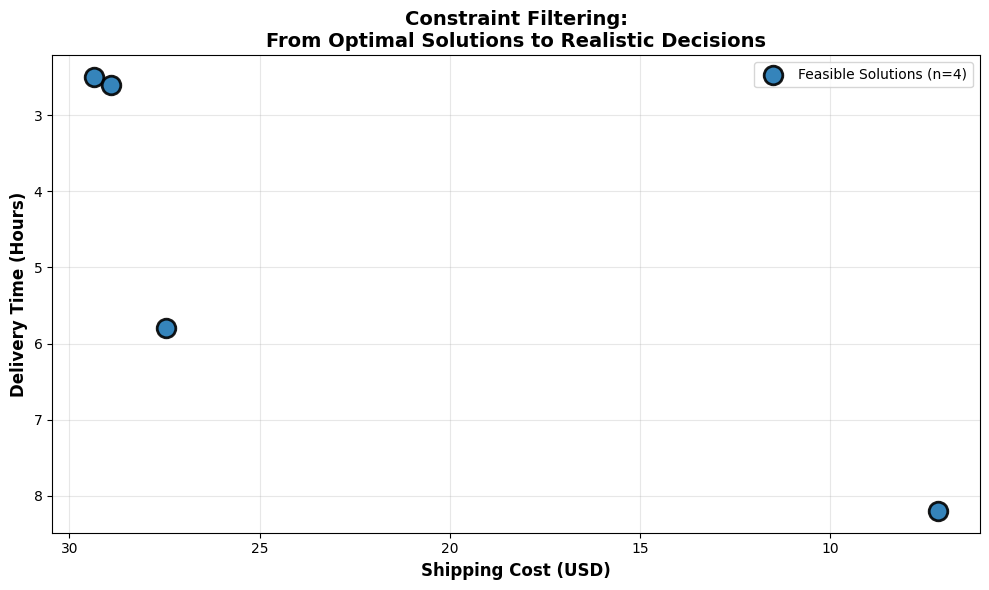


✓ Visualization saved as 'images/feasible_region.png'


In [18]:
# Create visualization showing original Pareto frontier vs feasible region
fig, ax = plt.subplots(figsize=(10, 6))

# Identify infeasible Pareto points
infeasible_df = pareto_df[~pareto_df.index.isin(feasible_df.index)]

# Plot infeasible Pareto points
if len(infeasible_df) > 0:
    ax.scatter(infeasible_df[OBJECTIVE_1], infeasible_df[OBJECTIVE_2],
               s=120, alpha=0.6,
               label=f'Pareto Optimal but Infeasible (n={len(infeasible_df)})',
               edgecolors='black', linewidth=1, marker='x')

# Plot feasible solutions
ax.scatter(feasible_df[OBJECTIVE_1], feasible_df[OBJECTIVE_2],
           s=180, alpha=0.9,
           label=f'Feasible Solutions (n={len(feasible_df)})',
           edgecolors='black', linewidth=2, marker='o')

# Labels (cleaned for executives)
ax.set_xlabel('Shipping Cost (USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Delivery Time (Hours)', fontsize=12, fontweight='bold')
ax.set_title('Constraint Filtering:\nFrom Optimal Solutions to Realistic Decisions',
             fontsize=14, fontweight='bold')

# VERY IMPORTANT: show minimization direction clearly
ax.invert_xaxis()
ax.invert_yaxis()

ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/feasible_region.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'images/feasible_region.png'")

In [19]:
if len(feasible_df) > 0:
    print("\n=== ALL FEASIBLE SOLUTIONS ===")
    
    display_df = feasible_df[
        ['distance_km', 'warehouse_load_pct', 'transport_mode',
         OBJECTIVE_1, OBJECTIVE_2]
    ].copy()
    
    display_df[OBJECTIVE_1] = display_df[OBJECTIVE_1].round(1)
    display_df[OBJECTIVE_2] = display_df[OBJECTIVE_2].round(1)
    
    print(display_df.to_string(index=False))


=== ALL FEASIBLE SOLUTIONS ===
 distance_km  warehouse_load_pct transport_mode  shipping_cost_usd  delivery_time_hours
       34.54                49.5       same_day               29.3                  2.5
       46.18                70.5       same_day               28.9                  2.6
        6.33                60.9         ground                7.2                  8.2
       51.20                67.8            air               27.5                  5.8


## Part 2.3: Implement Agent Decision Logic

## Agent Decision Logic

My agent uses the following heuristic rules to select the best solution from the feasible set:

**Priority 1: Customer Service (Delivery Speed)**
- If fast delivery is required (e.g., high-demand periods or Prime expectations), prioritize minimizing delivery time
- Rationale: Amazon’s competitive advantage is built on fast and reliable delivery, so meeting customer expectations is critical for retention and satisfaction

**Priority 2: Cost Efficiency (Profitability)**
- If budget constraints are tight or margins are a concern, prioritize minimizing shipping cost
- Rationale: Fulfillment and logistics costs significantly impact profitability, especially for lower-priced items, so cost control is essential for sustainable operations

**Priority 3: Operational Stability (Capacity Management)**
- If warehouse load is high, prioritize solutions with lower warehouse utilization
- Rationale: High warehouse load increases the risk of delays and inefficiencies, so maintaining operational stability helps ensure consistent performance

**Priority 4: Balanced Strategy (Fallback)**
- Default to the solution that minimizes the combined cost and delivery time
- Rationale: When no single priority dominates, a balanced approach provides a reasonable tradeoff between cost efficiency and service quality

The agent takes a `scenario` parameter describing current business conditions and applies these rules to recommend the most appropriate feasible solution.

In [20]:
class DecisionAgent:
    """
    Constraint-aware decision agent for logistics optimization
    """
    
    def __init__(self, feasible_solutions, obj1_col, obj2_col):
        self.feasible_solutions = feasible_solutions.copy()
        self.obj1_col = obj1_col  # shipping_cost_usd
        self.obj2_col = obj2_col  # delivery_time_hours
        
        if len(self.feasible_solutions) == 0:
            raise ValueError("No feasible solutions available for agent to choose from!")
    
    def recommend(self, scenario):
        candidates = self.feasible_solutions.copy()
        reasoning = []
        
        # IMPORTANT: lower is better (minimization)
        
        # Priority-based logic
        if scenario.get('priority') == 'cost':
            reasoning.append("Scenario prioritizes minimizing cost")
            best_idx = candidates[self.obj1_col].idxmin()
            reasoning.append("Selected lowest cost solution")
            
        elif scenario.get('priority') == 'speed':
            reasoning.append("Scenario prioritizes fast delivery")
            best_idx = candidates[self.obj2_col].idxmin()
            reasoning.append("Selected fastest delivery option")
            
        elif scenario.get('priority') == 'balanced':
            reasoning.append("Scenario requires balanced performance")
            candidates['total'] = candidates[self.obj1_col] + candidates[self.obj2_col]
            best_idx = candidates['total'].idxmin()
            reasoning.append("Selected lowest combined cost + time")
        
        # Urgency override
        elif scenario.get('urgency') == 'high':
            reasoning.append("High urgency detected → prioritizing speed")
            best_idx = candidates[self.obj2_col].idxmin()
            reasoning.append("Selected fastest feasible option")
        
        # Competitive pressure → speed matters more
        elif scenario.get('competitive_pressure') == 'high':
            reasoning.append("High competitive pressure → customer experience prioritized")
            best_idx = candidates[self.obj2_col].idxmin()
            reasoning.append("Selected fastest option to maintain competitiveness")
        
        # Default fallback (equity)
        else:
            reasoning.append("No dominant priority → using balanced equity strategy")
            candidates['gap'] = abs(candidates[self.obj1_col] - candidates[self.obj2_col])
            best_idx = candidates['gap'].idxmin()
            reasoning.append("Selected solution with most balanced outcomes")
        
        recommendation = candidates.loc[best_idx]
        
        return {
            'solution': recommendation,
            'reasoning': reasoning,
            'scenario': scenario
        }
    
    def explain_recommendation(self, recommendation_dict):
        solution = recommendation_dict['solution']
        reasoning = recommendation_dict['reasoning']
        scenario = recommendation_dict['scenario']
        
        explanation = "="*70 + "\n"
        explanation += "AGENT RECOMMENDATION\n"
        explanation += "="*70 + "\n\n"
        
        explanation += "BUSINESS SCENARIO:\n"
        for key, value in scenario.items():
            explanation += f"  • {key}: {value}\n"
        
        explanation += "\nRECOMMENDED DECISION:\n"
        explanation += f"  • Distance (km): {solution['distance_km']:.1f}\n"
        explanation += f"  • Warehouse Load (%): {solution['warehouse_load_pct']:.1f}\n"
        explanation += f"  • Transport Mode: {solution['transport_mode']}\n"
        
        explanation += "\nEXPECTED OUTCOMES:\n"
        explanation += f"  • Shipping Cost (USD): {solution[self.obj1_col]:.1f}\n"
        explanation += f"  • Delivery Time (Hours): {solution[self.obj2_col]:.1f}\n"
        
        explanation += "\nREASONING:\n"
        for i, reason in enumerate(reasoning, 1):
            explanation += f"  {i}. {reason}\n"
        
        explanation += "\n" + "="*70
        
        return explanation

In [23]:
# Test with a basic scenario
test_scenario = {
    'priority': 'balanced',
    'urgency': 'medium',
    'competitive_pressure': 'low'
}

print("\n=== TESTING AGENT ===\n")

if len(feasible_df) > 0:
    agent = DecisionAgent(feasible_df, OBJECTIVE_1, OBJECTIVE_2)
    recommendation = agent.recommend(test_scenario)
    explanation = agent.explain_recommendation(recommendation)
    print(explanation)
else:
    print("No feasible solutions available, so the agent cannot make a recommendation.")


=== TESTING AGENT ===

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: balanced
  • urgency: medium
  • competitive_pressure: low

RECOMMENDED DECISION:
  • Distance (km): 6.3
  • Warehouse Load (%): 60.9
  • Transport Mode: ground

EXPECTED OUTCOMES:
  • Shipping Cost (USD): 7.2
  • Delivery Time (Hours): 8.2

REASONING:
  1. Scenario requires balanced performance
  2. Selected lowest combined cost + time



In [24]:
scenarios = {
    "Balanced Scenario": {
        'priority': 'balanced',
        'urgency': 'medium',
        'competitive_pressure': 'low'
    },
    "Cost-Focused Scenario": {
        'priority': 'cost',
        'urgency': 'low',
        'competitive_pressure': 'low'
    },
    "High-Urgency Scenario": {
        'priority': 'speed',
        'urgency': 'high',
        'competitive_pressure': 'high'
    }
}

if len(feasible_df) > 0:
    agent = DecisionAgent(feasible_df, OBJECTIVE_1, OBJECTIVE_2)
    
    for scenario_name, scenario in scenarios.items():
        print(f"\n=== {scenario_name} ===\n")
        recommendation = agent.recommend(scenario)
        explanation = agent.explain_recommendation(recommendation)
        print(explanation)
else:
    print("No feasible solutions available, so the agent cannot make a recommendation.")


=== Balanced Scenario ===

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: balanced
  • urgency: medium
  • competitive_pressure: low

RECOMMENDED DECISION:
  • Distance (km): 6.3
  • Warehouse Load (%): 60.9
  • Transport Mode: ground

EXPECTED OUTCOMES:
  • Shipping Cost (USD): 7.2
  • Delivery Time (Hours): 8.2

REASONING:
  1. Scenario requires balanced performance
  2. Selected lowest combined cost + time


=== Cost-Focused Scenario ===

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: cost
  • urgency: low
  • competitive_pressure: low

RECOMMENDED DECISION:
  • Distance (km): 6.3
  • Warehouse Load (%): 60.9
  • Transport Mode: ground

EXPECTED OUTCOMES:
  • Shipping Cost (USD): 7.2
  • Delivery Time (Hours): 8.2

REASONING:
  1. Scenario prioritizes minimizing cost
  2. Selected lowest cost solution


=== High-Urgency Scenario ===

AGENT RECOMMENDATION

BUSINESS SCENARIO:
  • priority: speed
  • urgency: high
  • competitive_pressure: high

RECOMMENDED DECISION:
 

## Part 2.4: Test Agent Across Scenarios

## Part 2.5: Agent Explanation & Transparency

## Part 2.6: Final Recommendation